In [2]:
import pandas as pd
df = pd.read_csv("Russow.csv")
df.head() # Show the first few rows

,Location,Repository,PAFF,ORNPGLK,PROTO
0,Pärnu highway,AI,3,6,26
1,Pärnu highway,AI,1,1,4
2,Pärnu highway,AI,0,1,0
3,Roosikrantsi,AI,0,3,5
4,Roosikrantsi,AI,3,7,3


The dataset originates from the following article, Erki Russow. Tallinna lätted. – Tuna, 2019, 2, 10–26, pp. 22, 24, 26. I extracted a table from the article to Notepad++, where I used regex to clean it.	
I used two notepads for this - one to isolate numbers, one to isolate the location.  I experimented with my own knowledge, week 2's spreadsheet, and google searches.	
To separate the location, I used a simple search to delete everything after a specific keyword. This was done so I could easily copy paste the locations over and make generalisations for the dataset. Example with the word highway: in the search bar (highway).* -> replaced with \1 .	
Since every presented entry were in the AI repository (Archaeological Research Centre at TLU), I simply dragged the blue circle down the cells. 	
	
For numbers I used the search  .*\) that I then replaced with \1.  This meant I retained only the numbers as wanted. Every hyphen were later changed to 0.	
Eventually I searched \s+ and replaced it with \t in order to place everything in one consecutive row. After this I copied the row over to the spreadsheet. Since I could not find nor think of a search to automate this, I just pasted them to the respective cells. 	
	
The headings (PAFF, ORNPGLK, PROTO) originate from the legend prior to the tables. These are the types of ceramics & ware imported to Estonia and neighbouring regions - signs of colonialism in Tallinn. The table itself refers to the suburbs of medieval Tallinn, i.e Toompea. (Russow, 2019, pp. 22, 24, 26)	                                            
PAFF - Paffrath type pots;	
ORNPGLK - Ornamented red glazed pottery;	
PROTO - Proto-stoneware.

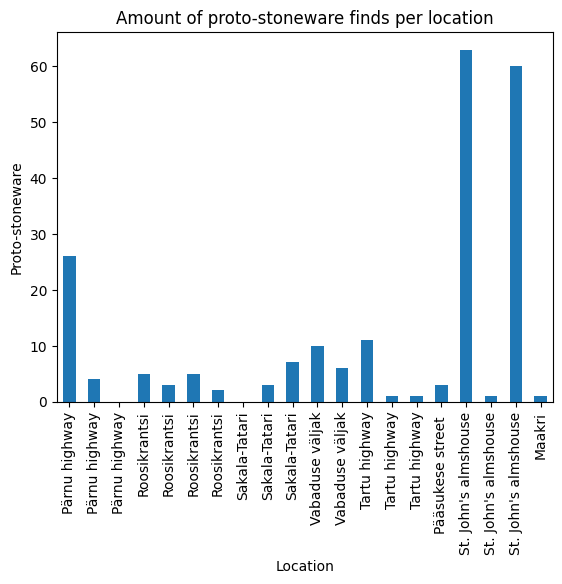

In [3]:
import matplotlib.pyplot as plt 
df.plot(kind="bar",x="Location",y="PROTO", legend=False)
df.groupby("Location")["PROTO"].count()
plt.title("Amount of proto-stoneware finds per location")
plt.ylabel("Proto-stoneware")
plt.show()

Here I added every proto-stoneware find per location as a whole. However, to simplify interpreting the chart, I used groupby. Hence I will interpret the chart in the next markdown cell. 

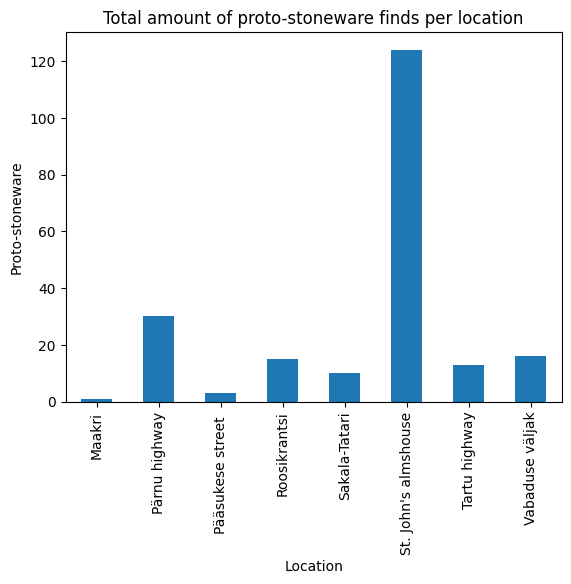

In [4]:
sum_PROTO=df.groupby("Location")["PROTO"].sum()
sum_PROTO.plot(kind="bar")
plt.title("Total amount of proto-stoneware finds per location")
plt.ylabel("Proto-stoneware")
plt.show()

Over 120 proto-stoneware finds were present around St. John's almshouse. This indicates that the almshouse, which function was to support those in need (the ill for example), needed to utilise a wide range of ware in order to accommodate large amounts of people. Not to mention the religious purpouse behind it - in Estonian it's known as Jaani Seek (St. John's sect). Thus this statistic furthermore illustrates that churches and similiar institutes could have prioritized preserving such ware more than the local peasants. Pärnu Highway, Roosikrantsi and Vabaduse Väljak, however, suggest that the outskirts of the main centre, Toompea, and churches etc. were just as important.

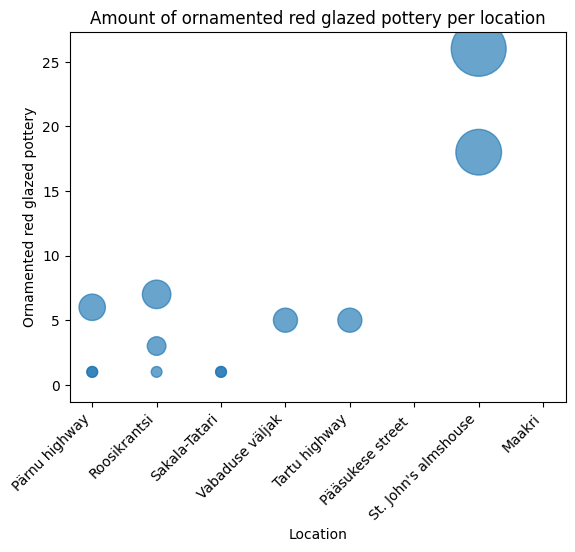

In [5]:
import matplotlib.pyplot as plt
plt.scatter(df["Location"], df["ORNPGLK"],s=df["ORNPGLK"]*60, alpha=0.67) 
plt.title("Amount of ornamented red glazed pottery per location")
plt.xlabel("Location")
plt.ylabel("Ornamented red glazed pottery")
plt.xticks(rotation=45, ha="right") #Used this to tilt text to the side :D
plt.show()

Once more St. John's almshouse leads for presumably the same reasons. Deriven from the name (ornamented, glazed), perhaps the clergy used such pottery to create an atmosphere closer to "heaven". Churches are after all bountiful with the smell of incense, artpieces and so on. A person who would go to an almshouse in this case could technically feel closer to God and feel healed better. Perhaps there existed a grain of greed aswell amongst the clergy, wanting to attain more aristocratic power. Interestingly the only entry to have more than three specific archaelogical finds is Roosikrantsi, which again alludes to the theory that Tallinn could have had a settlement around that region. Why else would there be an abundance of finds there once the colonists arrived?

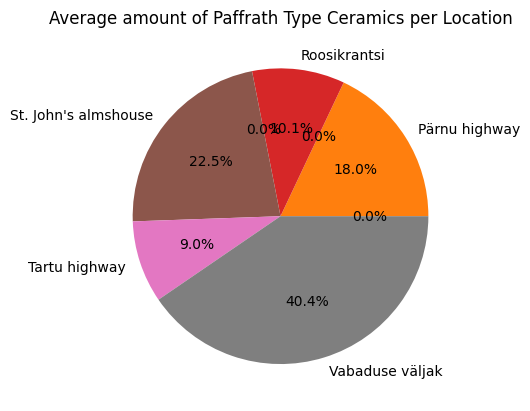

In [6]:
avg_paff=df.groupby("Location")["PAFF"].mean()
avg_paff.plot(kind="pie", autopct="%1.1f%%", legend=False)
plt.ylabel("")
plt.title("Average amount of Paffrath Type Ceramics per Location")
plt.show()

When the previous two analysed ornaments seemed to be found most in the almhouse, then Paffrath type ceramics, on average, were found more in Vabaduse väljak - but why? It lied outside city walls, effectivelly a suburb-like area. Perhaps the sea-level and medieval Estonian terrain were vastly different from the present-day. This could mean that merchants and travellers alike erected trade-posts, or other similiar buildings in-front of the city walls. This could have been encouraged, mayhap forced, by the elite, in order to let the Tallinn suburbs blossom.

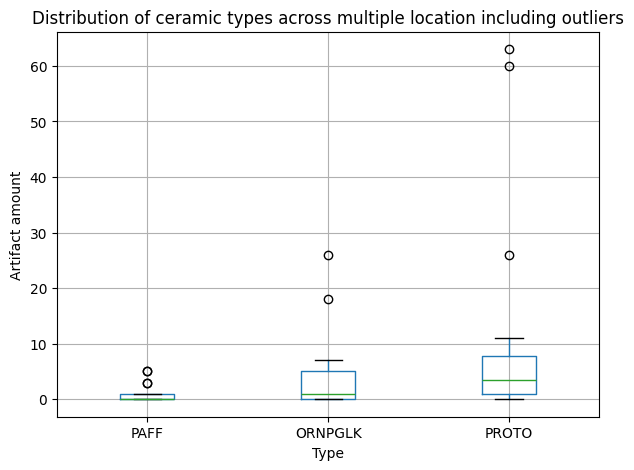

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 5)) 
df[["Location", "PAFF", "ORNPGLK", "PROTO"]].boxplot() 
plt.title("Distribution of ceramic types across multiple location including outliers")
plt.ylabel("Artifact amount",)
plt.xlabel("Type")
plt.show()

This boxplot chart shows three things:
1) There have been barely any paffrath-type finds in Tallinn suburbs. 
2) Eventhough there do exist concrete outliers, ornamented red glazed pottery have also relatively little finds.
3) Proto-stoneware is the most common type of ceramic here, and there are more outliers. They dwarf the rest of the statistics.                                                                                                                                                 
Therefore the results could illustrate that stone, atleast in materialistic culture, started becoming more popular. Additionally, given that all of these ceramics stemmed from the 13th century (Russow, 2019, p. 24), then one could say the colonisers helped cultivate Tallinn as a "true city", not just a random settlement located at a convenient area within the Baltic Sea. 